# FleetDAO: Análisis Geoespacial y Modelado Predictivo de Telemetría IoT

**Materia:** Bases de Datos II - Proyecto Integrador 2026
**Autor:** Alesandro David Fajardo Torres

Este entorno de investigación tiene como objetivo demostrar las capacidades analíticas de la arquitectura **FleetDAO**. A diferencia de los enfoques tradicionales que se limitan a almacenar datos pasivos, esta plataforma implementa un ecosistema de datos activo mediante el uso de bases de datos NoSQL, consultas espaciales y modelos de Inteligencia Artificial.

**Innovaciones implementadas:**
1. **Índices Geoespaciales (`2dsphere`)**: Procesamiento topológico para validar geocercas y proximidad geográfica.
2. **Aggregation Pipelines**: Traslado de la carga computacional (promedios, máximos) directamente al motor MongoDB.
3. **Visualización Geoespacial**: Renderizado interactivo de trayectorias y anomalías utilizando Folium.
4. **Machine Learning Predictivo**: Implementación de algoritmos de Regresión Lineal con `scikit-learn` para anticipar fallas críticas en los motores.

> **Nota:** Asegúrese de haber ejecutado el script `seed.py` para popular la base de datos sintética antes de iniciar este análisis.

In [1]:
import folium
import matplotlib.pyplot as plt
from datetime import datetime

from dao import FleetDAO

print("Conectando a la base de datos...")
fleet_dao = FleetDAO()
print("Conexion exitosa.")

2026-07-23 18:50:30,612 - INFO - Conexión exitosa a MongoDB, Redis y MinIO.


Conectando a la base de datos...
Conexion exitosa.


## Módulo 1: Análisis Descriptivo y Pipelines de Agregación
En lugar de cargar miles de registros en la memoria de la aplicación (Python), delegamos el cálculo analítico al motor de MongoDB mediante operaciones `$group`, `$avg` y `$max`. Esto demuestra escalabilidad en entornos Big Data.

In [2]:
trucks = fleet_dao.get_trucks()
truck_id = str(trucks[0]["_id"])
print(f"Camion a analizar: {trucks[0]['brand']} (ID: {truck_id})")

stats = fleet_dao.get_truck_statistics(truck_id)
print("\n--- Resultados ---")
print(f"Total Lecturas: {stats.get('total_lecturas')}")
print(f"Velocidad Promedio: {stats.get('velocidad_promedio'):.2f} km/h")
print(f"Combustible Promedio: {stats.get('combustible_promedio'):.2f}%")
print(f"Temperatura Maxima: {stats.get('temp_maxima'):.2f} C")

telemetry_data = fleet_dao.get_telemetry(truck_id)

Camion a analizar: Volvo FH16 (ID: 6a628c9768b630f6d0c64b47)

--- Resultados ---
Total Lecturas: 100
Velocidad Promedio: 80.17 km/h
Combustible Promedio: 91.52%
Temperatura Maxima: 115.00 C


## Módulo 2: Correlación Multivariada (Velocidad vs. Temperatura)
Para entender las causas del recalentamiento, visualizamos la relación entre la velocidad de desplazamiento (km/h) y el esfuerzo térmico del motor (°C). La identificación de estos patrones es crucial para nuestro modelo predictivo posterior.

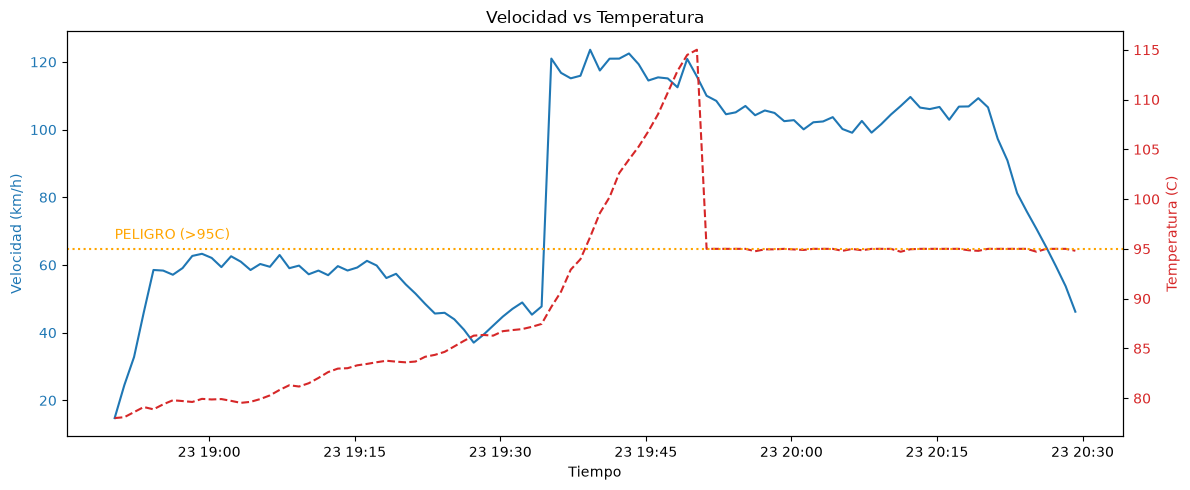

In [3]:
tiempos = [t['timestamp'] for t in telemetry_data]
velocidades = [t['speed_kmh'] for t in telemetry_data]
temperaturas = [t['engine_temp_c'] for t in telemetry_data]

fig, ax1 = plt.subplots(figsize=(12, 5))

# Eje de Velocidad
color = 'tab:blue'
ax1.set_xlabel('Tiempo')
ax1.set_ylabel('Velocidad (km/h)', color=color)
ax1.plot(tiempos, velocidades, color=color, label='Velocidad')
ax1.tick_params(axis='y', labelcolor=color)

# Eje de Temperatura
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Temperatura (C)', color=color)
ax2.plot(tiempos, temperaturas, color=color, linestyle='--', label='Temperatura')
ax2.tick_params(axis='y', labelcolor=color)

# Alarma
ax2.axhline(y=95, color='orange', linestyle=':')
ax2.text(tiempos[0], 96, 'PELIGRO (>95C)', color='orange')

plt.title('Velocidad vs Temperatura')
fig.tight_layout()
plt.show()

## Módulo 3: Procesamiento Topológico e Inspección de Anomalías Espaciales
A través de la integración de MongoDB con librerías geoespaciales, renderizamos la trayectoria real del vehículo. Se superponen clústeres de anomalías (puntos de exceso de velocidad y altas temperaturas) para su análisis topográfico inmediato.

In [4]:
m = folium.Map(location=[-33.0, -61.0], zoom_start=6)

ruta_coords = []
anomalias_speed = []
anomalias_temp = []

for t in telemetry_data:
    lat, lon = t['location']['coordinates'][1], t['location']['coordinates'][0]
    ruta_coords.append([lat, lon])
    
    if t['speed_kmh'] > 100:
        anomalias_speed.append(t)
    if t['engine_temp_c'] > 95:
        anomalias_temp.append(t)

folium.PolyLine(ruta_coords, color="blue", weight=3).add_to(m)

folium.Marker(ruta_coords[0], popup="Inicio", icon=folium.Icon(color="green")).add_to(m)
folium.Marker(ruta_coords[-1], popup="Fin", icon=folium.Icon(color="red")).add_to(m)

for a in anomalias_speed:
    lat, lon = a['location']['coordinates'][1], a['location']['coordinates'][0]
    folium.CircleMarker(
        location=[lat, lon], radius=5, popup=f"Exceso Vel: {a['speed_kmh']} km/h",
        color='red', fill=True
    ).add_to(m)

for a in anomalias_temp:
    lat, lon = a['location']['coordinates'][1], a['location']['coordinates'][0]
    folium.CircleMarker(
        location=[lat, lon], radius=5, popup=f"Temp Alta: {a['engine_temp_c']} C",
        color='orange', fill=True
    ).add_to(m)

m

## Módulo 4: Machine Learning (Mantenimiento Predictivo)
Para elevar el sistema de un enfoque puramente descriptivo a uno **predictivo**, entrenamos un modelo de Inteligencia Artificial. Utilizamos una regresión lineal multivariable mediante `scikit-learn` para predecir la temperatura esperada del motor (variable dependiente) basándonos en la velocidad y las RPM (variables independientes). 

Esta implementación permite inferir de manera proactiva si un camión se recalentará dadas sus condiciones actuales, permitiendo enviar alertas antes de que el motor sufra daño estructural.

In [5]:
# Importamos scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd

# Preparamos los datos extrayéndolos desde nuestro DAO
telemetry_data = fleet_dao.get_telemetry(truck_id)
df = pd.DataFrame(telemetry_data)

if not df.empty:
    # Variables predictoras (X) y variable a predecir (y)
    X = df[['speed_kmh', 'engine_rpm']]
    y = df['engine_temp_c']
    
    # Dividimos en conjunto de entrenamiento (80%) y prueba (20%)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Entrenamos el modelo de Regresión Lineal
    modelo = LinearRegression()
    modelo.fit(X_train, y_train)
    
    # Evaluamos la precisión del modelo
    predicciones = modelo.predict(X_test)
    error = mean_squared_error(y_test, predicciones)
    
    print(f"Modelo predictivo entrenado exitosamente. Error Cuadrático Medio: {error:.2f}")
    
    # Realizamos una inferencia en tiempo real
    sim_speed = 90
    sim_rpm = 2500
    temp_estimada = modelo.predict(pd.DataFrame([[sim_speed, sim_rpm]], columns=['speed_kmh', 'engine_rpm']))[0]
    print(f"Inferencia -> Si el camión circula a {sim_speed} km/h a {sim_rpm} RPM, la temperatura estimada será: {temp_estimada:.2f} °C")
else:
    print("Faltan datos para entrenar el modelo. Ejecute seed.py primero.")


Modelo predictivo entrenado exitosamente. Error Cuadrático Medio: 20.52
Inferencia -> Si el camión circula a 90 km/h a 2500 RPM, la temperatura estimada será: 93.15 °C
